**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from BestFit.

# 05. Spatial Extremes
Spatial extremes analysis extends classical univariate extreme value theory to multiple locations, enabling regional flood frequency analysis with rigorous uncertainty quantification. This chapter provides a comprehensive introduction to spatial GEV modeling using Bayesian Hierarchical Models (BHM), suitable for readers with foundational knowledge of probability and statistics but limited exposure to spatial statistics or extreme value theory.

## What You'll Learn
- Spatial regression
- Spatial correlation
- Gaussian Copula
- Bayesian hierarchical modeling
- Estimating 100 and 500 year floods

We will follow this Spatial GEV Analysis Workflow: 
1. Generate or import annual maximum series at multiple sites.
2. Define spatial covariates.
3. Build regression relationships for GEV parameters.
4. Specify spatial correlation structures.
5. Optionally model inter-site dependence with a Gaussian copula.
6. Estimate parameters using Bayesian MCMC.
7. Compute return levels.
8. Quantify uncertainty and compare sites.

## Set Up

In [11]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

from RMC.BestFit.Models.TrendFunctions import GeneralLinearFunction
from RMC.BestFit.Models.SpatialExtremes import SpatialGEV, SpatialRegressionErrors, BasicExponential, PoweredExponential, Spherical, CorrelationFunctionType, GaussianCopula
from RMC.BestFit.Analyses import SpatialGEVAnalysis

from Numerics.Distributions import GeneralizedExtremeValue
from Numerics.Data.Statistics import Correlation

from System import Array, Double, Random

print("✓ Imported namespaces successfully")

✓ Numerics loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\Numerics.dll
✓ BestFit loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\RMC.BestFit.dll
✓ Imported namespaces successfully


## Spatial Regression on GEV Parameters

### Link Functions

GEV parameters have natural constraints that require appropriate link functions:
- **Location ($\xi$)**: Often positive for flood data, so log-link ensures positivity
- **Scale ($\alpha$)**: Must be positive, so log-link is essential
- **Shape ($\kappa$)**: Typically small ($|\kappa| < 0.5$), so identity link with bounded priors

### Location Parameter

With log-link:

$$
\log(\xi_j) = \beta_0^\xi + \beta_1^\xi X_{1j} + \beta_2^\xi X_{2j} + \cdots + \beta_K^\xi X_{Kj}
$$

Equivalently:

$$
\xi_j = \exp\left(\beta_0^\xi + \sum_{k=1}^K \beta_k^\xi X_{kj}\right)
$$

**Interpretation**: Regression coefficients represent multiplicative effects. A unit increase in covariate $X_k$ multiplies location by $\exp(\beta_k^\xi)$.

### Scale Parameter

With log-link:

$$
\log(\alpha_j) = \beta_0^\alpha + \sum_{k=1}^K \beta_k^\alpha X_{kj}
$$

This ensures $\alpha_j > 0$ for all covariate values.

### Shape Parameter

With identity link:

$$
\kappa_j = \beta_0^\kappa + \sum_{k=1}^K \beta_k^\kappa X_{kj}
$$

Shape is kept near zero through bounded priors, typically $|\kappa_j| < 0.5$.

### Common Covariates

For spatial flood frequency analysis, useful covariates include:

| Covariate | Symbol | Effect on Floods |
|-----------|--------|------------------|
| Longitude | $X$ | East-west climate gradients |
| Latitude | $Y$ | North-south climate gradients |
| Elevation | $Z$ | Orographic precipitation effects |
| Drainage area | $A$ | Larger basins → larger floods |
| Mean precipitation | $P$ | Wetter regions → larger floods |
| Basin slope | $S$ | Steeper basins → faster concentration |


In [ ]:
def create_test_site_data():
    '''
    Generate synthetic regional flood dataset of 30 years of annual maximum discharge data for 5 sites.
    Each column represents a site, and each row represents on year of annual maximum flow.
    In practice these values would come from stream gage observations.
    '''

    data = Array.CreateInstance(Double, 30, 5)

    rng = Random(12345) 
    gev = GeneralizedExtremeValue(10000.0, 2500.0, 0.0)

    for site in range(5):
        for year in range(30):
            data[year,site] = gev.InverseCDF(rng.NextDouble())

    return data

coordinate_values = [
    [0.0, 0.0],
    [10.0, 5.0],
    [22.0, 8.0],
    [35.0, 12.0],
    [50.0, 15.0]
]

test_coordinates = Array.CreateInstance(Double, 5, 2)

for i in range(5):
    for j in range(2):
        test_coordinates[i, j] = coordinate_values[i][j]

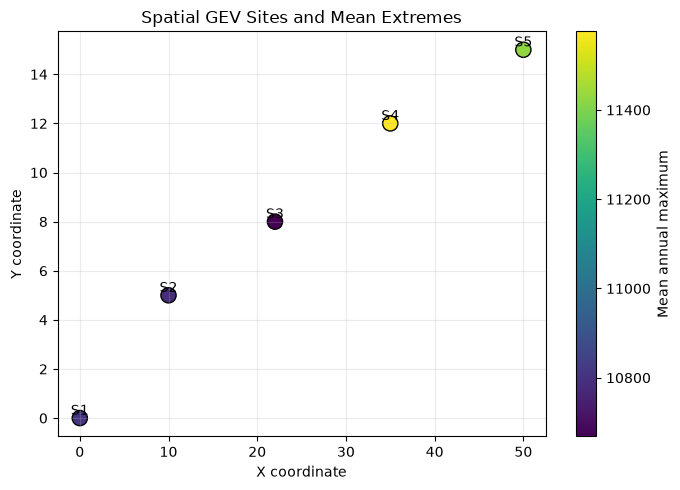

In [3]:
# Prepare site data (n_obs x n_sites matrix)
data =  create_test_site_data()

# Plot the spatial sites and each site's sample mean annual maximum.
coords = np.array([[float(test_coordinates[i, 0]), float(test_coordinates[i, 1])] for i in range(test_coordinates.GetLength(0))])
site_means = np.array([
    np.mean([float(data[row, col]) for row in range(data.GetLength(0))])
    for col in range(data.GetLength(1))
])
plt.figure(figsize=(7, 5))
points = plt.scatter(coords[:, 0], coords[:, 1], c=site_means, s=120, cmap="viridis", edgecolor="black")
for i, (x_coord, y_coord) in enumerate(coords, start=1):
    plt.text(x_coord, y_coord, f"S{i}", ha="center", va="bottom")
plt.colorbar(points, label="Mean annual maximum")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Spatial GEV Sites and Mean Extremes")
plt.grid(alpha=0.25)
plt.tight_layout()

# Create covariate matrix (X and Y coordinates)
n_sites = test_coordinates.GetLength(0)
covariates = Array.CreateInstance(Double, n_sites, 2)
for j in range(n_sites):
    covariates[j, 0] = test_coordinates[j, 0] # X
    covariates[j, 1] = test_coordinates[j, 1] # Y

# Create GeneralLinearFunction for each parameter
location = GeneralLinearFunction("Location", covariates)
scale = GeneralLinearFunction("Scale", covariates)
shape = GeneralLinearFunction("Shape") # Intercept only

# Create spatial GEV model
model = SpatialGEV(data, test_coordinates, location, scale, shape)
model.UseLogLinkForLocation = True
model.UseLogLinkForScale = True

### Interpreting the Site Map

- Each point represents a monitoring location.
- Color indicates the sample mean annual maximum flood magnitude.
- Sites closer together typically exhibit stronger spatial dependence due to shared weather systems and climatic influences.
- Spatial regression attempts to explain observed differences among sites using geographic coordinates and watershed characteristics.

**Note on Synthetic Data:** This synthetic example was generated from the same underlying GEV distribution at all sites. Because of this, any visible spatial patterns arise purely from sampling variability and do not reflect true geographic heterogeneity. In a real application, covariates such as drainage area, elevation, precipitation, or climate region would typically explain systematic differences in flood magnitudes among sites.

## Spatial Correlation Structures

Spatial correlation functions describe how similarity between locations decreases with distance. Let $h = \|\mathbf{s}_i - \mathbf{s}_j\|$ denote the Euclidean distance between sites $i$ and $j$. The correlation function $\rho(h)$ must satisfy:
- $\rho(0) = 1$ (perfect correlation at zero distance)
- $0 \leq \rho(h) \leq 1$ for all $h \geq 0$
- $\rho(h) \to 0$ as $h \to \infty$ (decay to independence)
- Positive definiteness (required for valid covariance matrices)

### Basic Exponential

$$
\rho(h) = \exp\left(-\frac{h}{r}\right)
$$

where $r > 0$ is the **range** (or **scale**) parameter.

**Properties**:
- Exponential decay with distance
- Practical range (correlation drops to 0.05): approximately $3r$
- Infinitely divisible (valid for any positive definite operation)
- Non-differentiable at the origin (rough process realizations)

**When to use**: Default choice; robust and widely applicable.

### Powered Exponential

$$
\rho(h) = \exp\left(-\left(\frac{h}{r}\right)^p\right)
$$

where $r > 0$ is the range and $0 < p \leq 2$ is the **power** parameter.

**Special cases**:
- $p = 1$: Basic exponential
- $p = 2$: Gaussian (squared exponential)

**Properties**:
- Higher $p$ gives smoother correlation decay
- Gaussian ($p = 2$) produces infinitely differentiable (smooth) process realizations
- Practical range varies with $p$

**When to use**: When process smoothness is important; $p \approx 1.5$ often works well.

### Spherical

$$
\rho(h) = \begin{cases}
1 - \frac{3h}{2r} + \frac{h^3}{2r^3} & \text{if } h < r \\
0 & \text{if } h \geq r
\end{cases}
$$

**Properties**:
- **Compact support**: Exactly zero correlation beyond range $r$
- Computational advantage for large networks (sparse correlation matrices)
- Transition from correlation to independence at distance $r$

**When to use**: When distant sites are believed truly independent; reduces computational burden.

### Comparison

| Property | Basic Exponential | Powered Exponential | Spherical |
|----------|-------------------|---------------------|-----------|
| Parameters | 1 (range) | 2 (range, power) | 1 (range) |
| Smoothness | Rough | Adjustable | Moderate |
| Compact support | No | No | Yes |
| Computation | O(S²) | O(S²) | O(S² sparse) |

### Evaluating Correlation Functions
Each correlation function takes a `Range` (and, for the powered exponential, a `Power`) and returns the correlation at a given separation distancce. Below we evaluated each function at a distance of 9 units to compare how quickly they decay. The result can be interpreted as the expected correlation between two locations separated by that distance. For example if the correlation = 0.75, then approximately 75% of variability is shared. Whereas if the correlation = 0.10, the the locations are nearly independent.

Basic exponential @ d=9: 0.4065696597405991
Powered exponential @ d=9: 0.42578746389901556
Spherical @ d=9: 0.014499999999999957


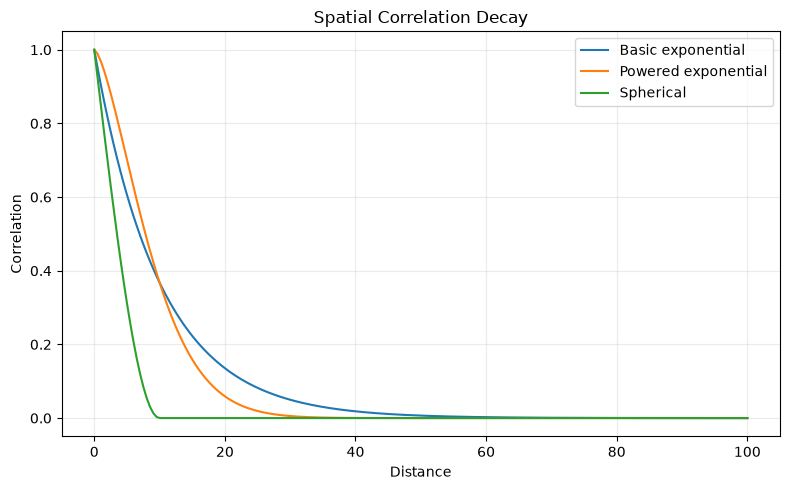

In [ ]:
basic_exp = BasicExponential()
basic_exp.Range = 30
print("Basic exponential @ d=9:", basic_exp.Evaluate(9))

power_exp = PoweredExponential()
power_exp.Range = 30
power_exp.Power = 1.5
print("Powered exponential @ d=9:", power_exp.Evaluate(9))

spherical = Spherical()
spherical.Range = 50 
print("Spherical @ d=9:", spherical.Evaluate(9))

# Spatial correlation decay by distance
x = np.linspace(0,100,200)
plt.figure(figsize=(8,5))
for name, fn in {"Basic exponential": basic_exp, "Powered exponential": power_exp, "Spherical": spherical}.items():
    plt.plot(x, [fn.Evaluate(float(d)) for d in x], label=name)
plt.xlabel("Distance"); plt.ylabel("Correlation"); plt.title("Spatial Correlation Decay"); plt.grid(alpha=.25); plt.legend(); plt.tight_layout()

In the graph above all functions being at 1.0 when distance is zero. Correlation decreases as separation increases. A faster decay implies more localized spatial influence versus a slow decay implies regional-scale dependence. Notice that the spherical model reaches exactly zero at it's specified range.

### Spatial Errors
We can now use our understanding of these correlation structures to define error terms in our model. Regression surfaces rarely explain all geographic variability. Spatially correlated errors allow neighboring sites to share unexplained behavior.

**Without spatial errors:** Site differences are explained only by covariates.

**With spatial errors:** Nearby sites borrow information from one another.


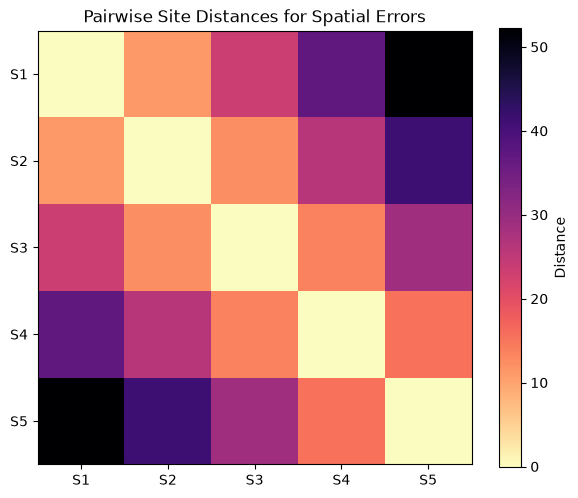

In [ ]:
# Create spatial error model using exponential correlation function
# Spatial errors allow neighboring sites to share unexplained residual variation
loc_errors = SpatialRegressionErrors(test_coordinates, CorrelationFunctionType.Exponential)
scl_errors = SpatialRegressionErrors(test_coordinates, CorrelationFunctionType.Exponential)

# Enable spatial errors for both location and scale parameters
model.UseLocationErrors = True
model.LocationErrors = loc_errors
model.UseScaleErrors = True
model.ScaleErrors = scl_errors

model.SetDefaultParameters()

# Plot pairwise site distances that drive the spatial regression error structure
coords = np.array([[float(test_coordinates[i, 0]), float(test_coordinates[i, 1])] for i in range(test_coordinates.GetLength(0))])
distance_matrix = np.zeros((len(coords), len(coords)))
for i in range(len(coords)):
    for j in range(len(coords)):
        distance_matrix[i, j] = np.sqrt(np.sum((coords[i] - coords[j]) ** 2))
plt.figure(figsize=(6, 5))
plt.imshow(distance_matrix, cmap="magma_r")
plt.colorbar(label="Distance")
plt.xticks(range(len(coords)), [f"S{i+1}" for i in range(len(coords))])
plt.yticks(range(len(coords)), [f"S{i+1}" for i in range(len(coords))])
plt.title("Pairwise Site Distances for Spatial Errors")
plt.tight_layout()

## Gaussian Coupula for Inter-Site Dependence
When analyzing regional extremes, observations at different sites in the same year are typically not independent—a major storm produces large floods at multiple nearby stations. A **copula** models this dependence structure separately from the marginal distributions [[1]](#1).

**Sklar's Theorem**: Any multivariate distribution can be decomposed as:

$$
F(y_1, \ldots, y_S) = C(F_1(y_1), \ldots, F_S(y_S))
$$

where $F_j$ are the marginal CDFs and $C: [0,1]^S \to [0,1]$ is the copula function capturing dependence.

### The Gaussian Copula

The Gaussian copula is defined through the multivariate normal distribution:

$$
C(u_1, \ldots, u_S) = \Phi_{\mathbf{R}}(\Phi^{-1}(u_1), \ldots, \Phi^{-1}(u_S))
$$

where:
- $\Phi$ is the standard normal CDF
- $\Phi^{-1}$ is the standard normal quantile function
- $\Phi_{\mathbf{R}}$ is the CDF of the multivariate normal with correlation matrix $\mathbf{R}$

For flood frequency analysis, the Gaussian copula is typically adequate because:
- Annual maxima from different sites have moderate dependence
- Primary interest is in marginal quantiles, not joint exceedance probabilities
- More complex copulas (e.g., extreme-value copulas) add parameters without clear practical benefit

### Physical Interpretation

Imagine a large regional storm affecting all watersheds simultaneously. Each site retains its own GEV distribution, but the copula links them through a common dependence structure.

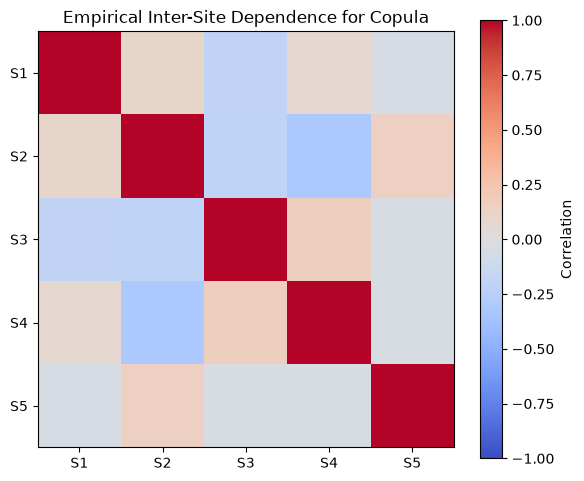

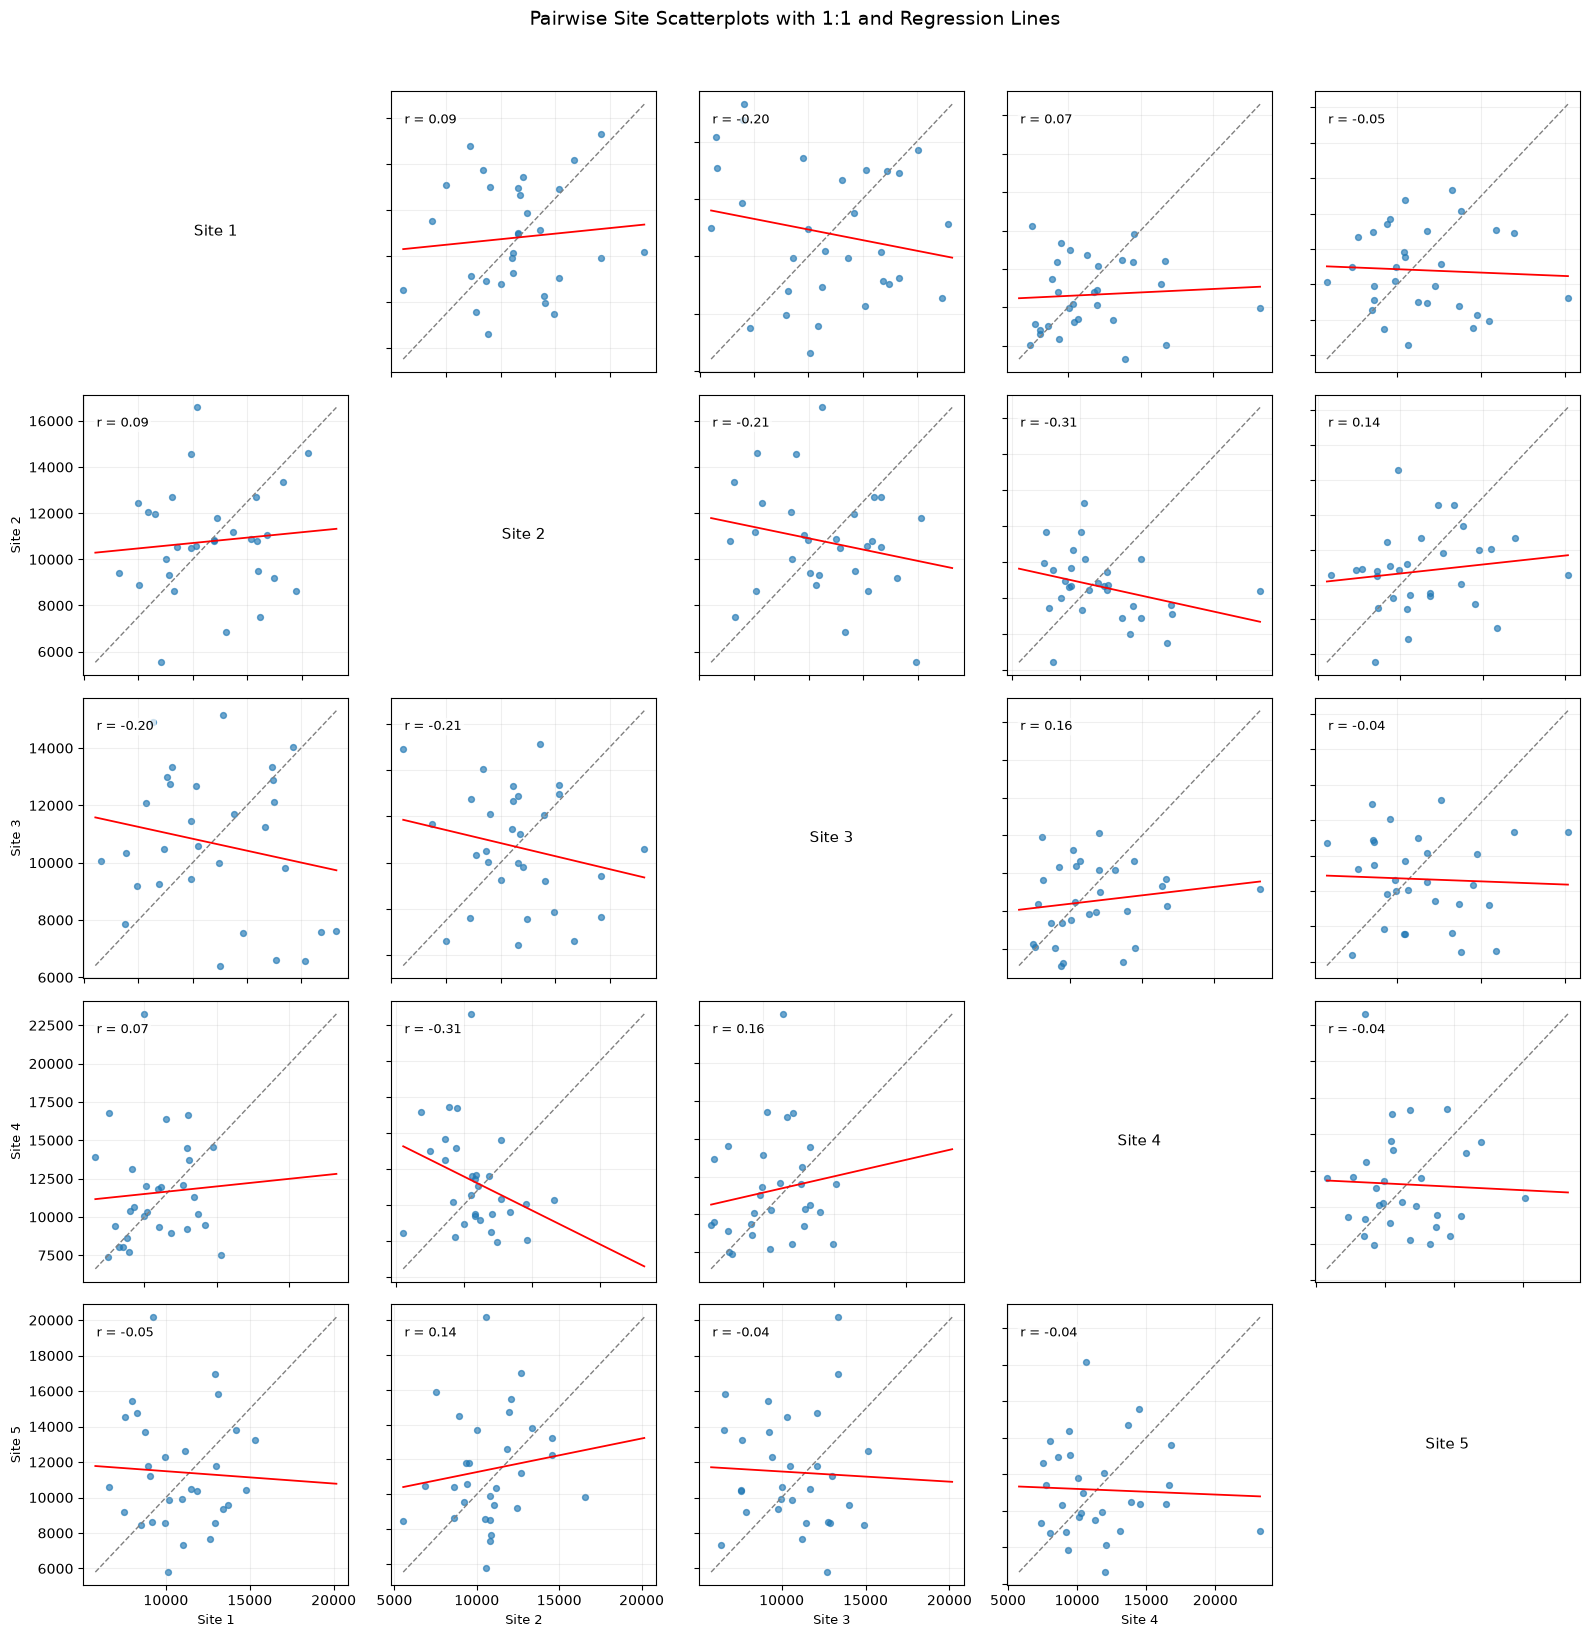

In [ ]:
# Create Gaussian copula with exponential correlation
copula = GaussianCopula(test_coordinates, CorrelationFunctionType.Exponential)

model.UseCopulaDependence = True
model.SpatialDependence = copula

model.SetDefaultParameters()

# Plot empirical same-year dependence across sites for the copula model context.
site_values = np.array([[float(data[row, col]) for col in range(data.GetLength(1))] for row in range(data.GetLength(0))])
# We could use Numerics' implementation of correlation, but it would require nested loops so we use numpy's corrcoef instead
corr = np.corrcoef(site_values, rowvar=False)
plt.figure(figsize=(6, 5))
plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(corr.shape[0]), [f"S{i+1}" for i in range(corr.shape[0])])
plt.yticks(range(corr.shape[0]), [f"S{i+1}" for i in range(corr.shape[0])])
plt.title("Empirical Inter-Site Dependence for Copula")
plt.tight_layout()

site_values = np.asarray(site_values, dtype=float)
n_years, n_sites = site_values.shape
site_labels = [f"Site {i+1}" for i in range(n_sites)]
corr_matrix = np.corrcoef(site_values, rowvar=False)

fig, axes = plt.subplots(n_sites, n_sites, figsize=(3.2 * n_sites, 3.2 * n_sites), squeeze=False)

for i in range(n_sites):
    for j in range(n_sites):
        ax = axes[i, j]

        if i == j:
            ax.text(0.5, 0.5, site_labels[i], ha="center", va="center", fontsize=11)
            ax.set_axis_off()
            continue

        x = site_values[:, j]
        y = site_values[:, i]

        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        ax.scatter(x, y, s=18, alpha=0.65)

        xy_min = min(np.min(x), np.min(y))
        xy_max = max(np.max(x), np.max(y))
        line_x = np.linspace(xy_min, xy_max, 100)

        ax.plot(line_x, line_x, color="gray", linestyle="--", linewidth=1)
        slope, intercept = np.polyfit(x, y, 1)
        ax.plot(line_x, intercept + slope * line_x, color="red", linewidth=1.3)

        r = corr_matrix[j, i]
        ax.text(
            0.05, 0.92, f"r = {r:.2f}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none")
        )

        ax.grid(alpha=0.20)

        if i == n_sites - 1:
            ax.set_xlabel(site_labels[j], fontsize=9)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(site_labels[i], fontsize=9)
        else:
            ax.set_yticklabels([])

plt.suptitle("Pairwise Site Scatterplots with 1:1 and Regression Lines", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

The scatter plots above provide a visual complement to the correlation matrix by showing the strength, direction, and shape of dependance, as well as any obvious outlier or nonlinear behavior. We can see that none of our sites seems to have a strong linear correlation with each other.

## Bayesian Hierarchical Model
The spatial GEV model follows the hierarchical framework developed by Renard et al. [[2]](#2), [[3]](#3), consisting of three levels. Recall the Bayesian MCMC estimation we have discussed through this demo. Those have all been models with one level so far. We can expand the Bayesian framework to include different levels that account for between-group and within-group variation. This makes a Bayesian Hierarchical model. The spatial GEV hierarchical model is as follows

### Level 1: Data Model

At each site $j \in \{1, \ldots, S\}$ with $n_j$ observations:

$$
Y_{ij} \mid \theta_j \sim \text{GEV}(\xi_j, \alpha_j, \kappa_j), \quad i = 1, \ldots, n_j
$$

where $\theta_j = (\xi_j, \alpha_j, \kappa_j)$ are the site-specific GEV parameters.

**Spatial Dependence**: Within a given year, observations across sites may be correlated (e.g., a regional storm produces high flows at multiple stations simultaneously). This dependence is captured through a Gaussian copula.

### Level 2: Process Model

GEV parameters at each site are functions of:
1. **Spatial regression**: Linear functions of covariates (location, elevation, drainage area, etc.)
2. **Spatially correlated errors**: Gaussian process deviations from the regression surface

For the location parameter with log-link:

$$
\log(\xi_j) = \beta_0^\xi + \beta_1^\xi X_{1j} + \beta_2^\xi X_{2j} + \varepsilon_j^\xi
$$

where:
- $\beta_0^\xi$ is the intercept
- $\beta_k^\xi$ are regression coefficients
- $X_{kj}$ are covariate values at site $j$ (e.g., latitude, longitude, elevation)
- $\varepsilon_j^\xi$ is a spatially correlated error term

The vector of errors $\boldsymbol{\varepsilon}^\xi = (\varepsilon_1^\xi, \ldots, \varepsilon_S^\xi)$ follows:

$$
\boldsymbol{\varepsilon}^\xi \sim \mathcal{N}(\mathbf{0}, \sigma_\xi^2 \mathbf{R}_\xi)
$$

where $\mathbf{R}_\xi$ is a correlation matrix determined by a spatial correlation function.

### Level 3: Prior Model

Hyperparameters (regression coefficients, error variance, correlation parameters) receive prior distributions:

$$
\begin{aligned}
\beta_k^\xi &\sim \text{Uniform}(L_\beta, U_\beta) \\
\sigma_\xi &\sim \text{Uniform}(0, U_\sigma) \text{ or Jeffreys prior} \\
\text{range} &\sim \text{Uniform}(0, U_r)
\end{aligned}
$$

**Note:** The final model below is rebuilt from scratch for the full Bayesian run and does not carry over the `UseLocationErrors`/`UseScaleErrors`/`UseCouplaDependence` settings configured in the earlier demo cells. If you want those spatial error/copula settings included in the Bayesian analysis, re-apply them to `model` before constructing `SpatialGEVAnalysis`.

DIC:       2804.390
WAIC:      2804.654
LOOIC:     2802.559

Parameter                 Mean        SD  Lower CI  Upper CI    Rhat     ESS
Location.β₀              9.173     0.043     9.102     9.243   1.000    2951
Location.β₁              0.002     0.008    -0.011     0.015   1.000    3154
Location.β₂             -0.003     0.026    -0.046     0.039   1.000    3091
Scale.β₀                 7.664     0.133     7.455     7.887   1.000    3217
Scale.β₁                 0.003     0.022    -0.033     0.040   1.000    3190
Scale.β₂                 0.008     0.075    -0.117     0.130   1.000    3158
Shape.β₀                 0.079     0.054    -0.015     0.161   1.000    2997

Site Index: 0
 100-year flood: 18009.783
 500-year flood: 20371.759

Site Index: 1
 100-year flood: 18620.567
 500-year flood: 21141.338

Site Index: 2
 100-year flood: 19269.578
 500-year flood: 21933.813

Site Index: 3
 100-year flood: 20104.169
 500-year flood: 22964.011

Site Index: 4
 100-year flood: 21074.078
 500-

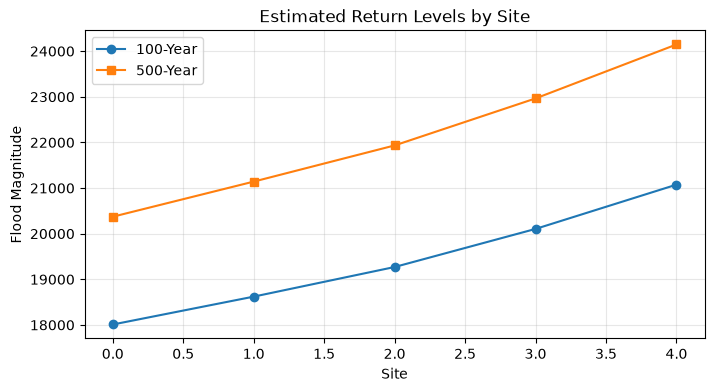

In [ ]:
model = SpatialGEV(data, test_coordinates, location, scale, shape)
model.UseLogLinkForLocation = True
model.UseLogLinkForScale = True

analysis = SpatialGEVAnalysis(model)

# Configure MCMC
analysis.BayesianAnalysis.Iterations = 20000
analysis.BayesianAnalysis.WarmupIterations = 10000
analysis.BayesianAnalysis.ThinningInterval = 10
analysis.BayesianAnalysis.NumberOfChains = 4

# Run analysis
analysis.RunAsync().Wait()

# Model fit metrics 
results = analysis.BayesianAnalysis.Results

print(f"DIC:       {analysis.BayesianAnalysis.DIC:.3f}")
print(f"WAIC:      {analysis.BayesianAnalysis.WAIC:.3f}")
print(f"LOOIC:     {analysis.BayesianAnalysis.LOOIC:.3f}\n")


print(
    f"{'Parameter':<20}"
    f"{'Mean':>10}"
    f"{'SD':>10}"
    f"{'Lower CI':>10}"
    f"{'Upper CI':>10}"
    f"{'Rhat':>8}"
    f"{'ESS':>8}"
)

for i in range(model.Parameters.Count):
    s = analysis.BayesianAnalysis.Results.ParameterResults[i].SummaryStatistics

    print(
        f"{model.Parameters[i].Name :<20}"
        f"{s.Mean:>10.3f}"
        f"{s.StandardDeviation:>10.3f}"
        f"{s.LowerCI:>10.3f}"
        f"{s.UpperCI:>10.3f}"
        f"{s.Rhat:>8.3f}"
        f"{s.ESS:>8.0f}"
    )

sites = []
f100 = []
f500 = []

for site_result in analysis.SiteResults:
    print(f"\nSite Index: {site_result.SiteIndex}")
    probs = list(site_result.Probabilities)     # Pull all exceedance probabilities for the quantile curves

    idx100 = probs.index(0.01)      # Exceedance probability for 100 year flood
    idx500 = probs.index(0.002)     # Exceedance probability for 500 year flood

    print(f" 100-year flood: {site_result.QuantileMean[idx100]:.3f}")
    print(f" 500-year flood: {site_result.QuantileMean[idx500]:.3f}")

    sites.append(site_result.SiteIndex)
    f100.append(site_result.QuantileMean[idx100])
    f500.append(site_result.QuantileMean[idx500])

plt.figure(figsize=(8,4))

plt.plot(sites, f100, "o-", label="100-Year")
plt.plot(sites, f500, "s-", label="500-Year")

plt.xlabel("Site")
plt.ylabel("Flood Magnitude")
plt.title("Estimated Return Levels by Site")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Summary
In this notebook you:             
$\checkmark$ Explored regression-based location and scale parameters        
$\checkmark$ Calculated inter-site dependence with spatial correlation functions        
$\checkmark$ Calculated inter-site dependence with a Gaussian copula        
$\checkmark$ Ran a Bayesian hierarchical model      
$\checkmark$ Estimated site-specific 100 and 500 year flood return levels       

## Exercises
1. Add covariates (elevation, area) to `GeneralLinearFunction` instead of intercept-only
2. Compare return-level estimates with and without `UseCopulaDependence` enabled


## References
<a id="1">[1]</a>
B. Renard and M. Lang, "Use of a Gaussian copula for multivariate extreme value analysis: Some case studies in hydrology", *Advances in Water Resources*, vol. 30, no. 4, pp. 897-912, 2007.

<a id="2">[2]</a>
B. Renard, V. Garreta, and M. Lang, "An application of Bayesian analysis and MCMC methods to the estimation of a regional trend in annual maxima", *Water Resources Research*, vol. 42, W12422, 2006.

<a id="3">[3]</a>
B. Renard, "A Bayesian hierarchical approach to regional frequency analysis", *Water Resources Research*, vol. 47, W11513, 2011.